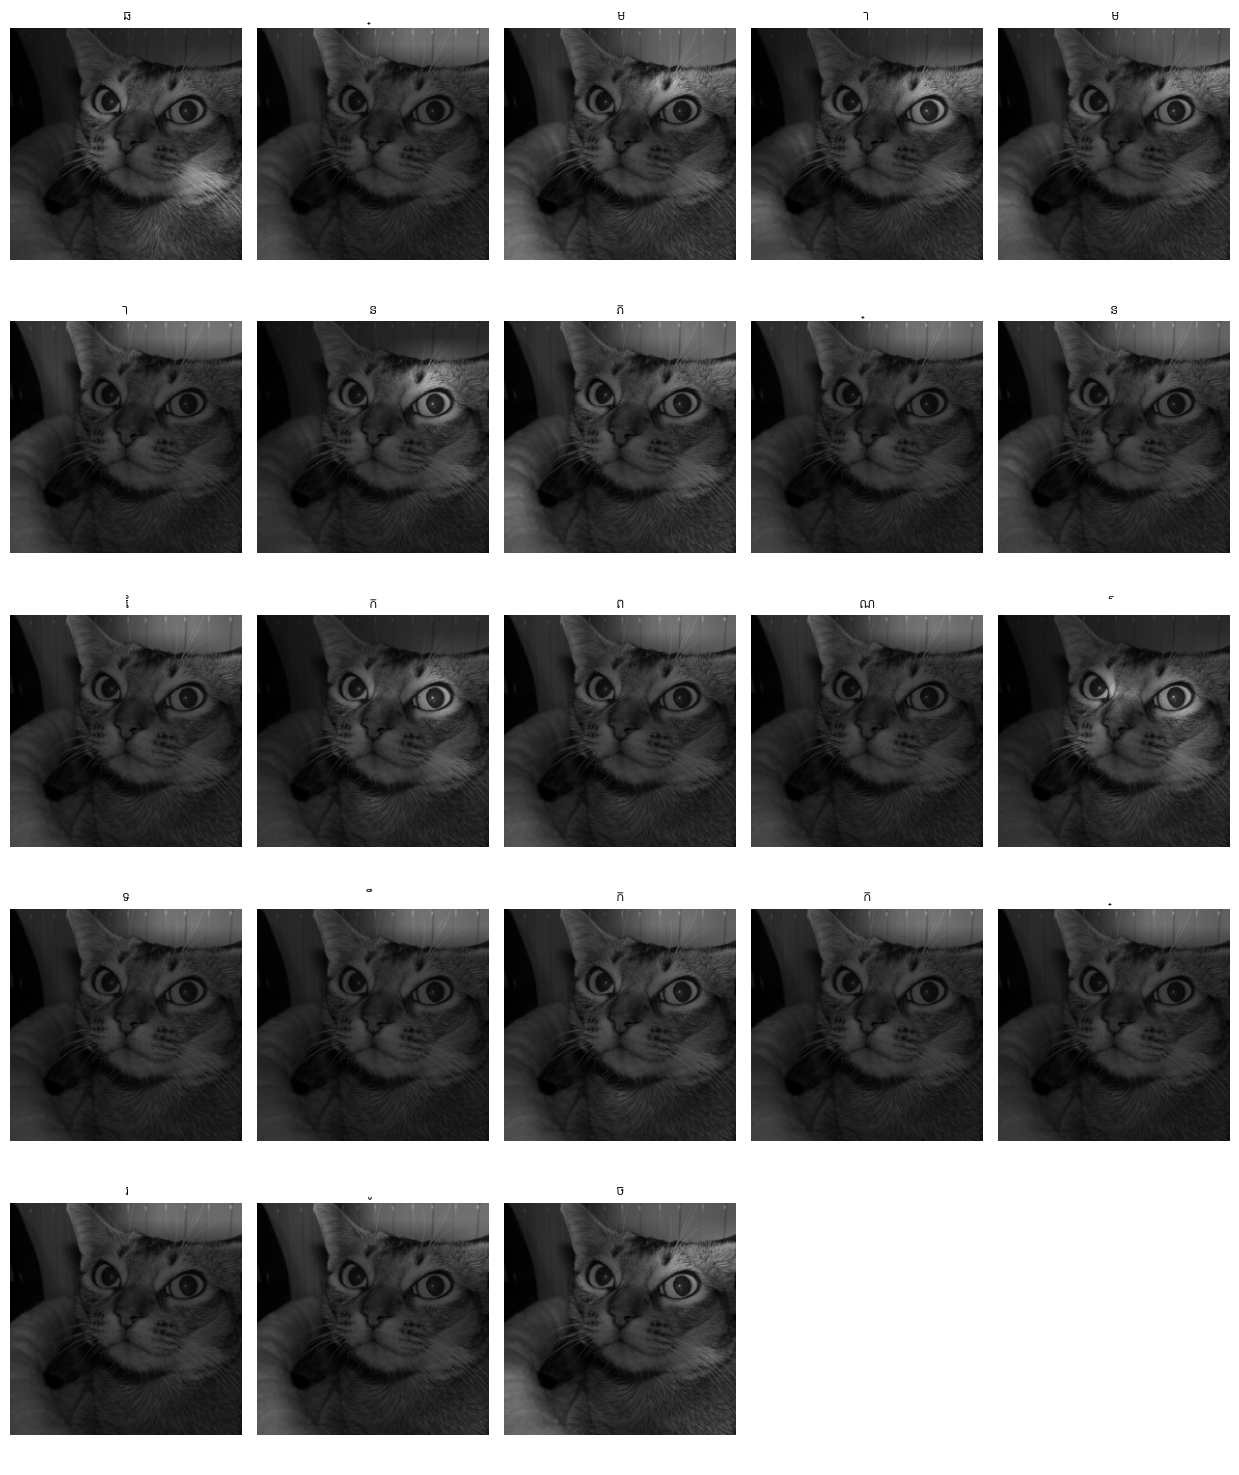

Generated Caption: ឆ្មាមានភ្នែកពណ៌ទឹកក្រូច


In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm
import math

# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention Module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

class EncoderCNN(nn.Module):
    def __init__(self):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        
        # Extract layers for multi-level feature extraction
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool  # First block max pooling
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        # Adaptive pooling for different feature levels
        self.adaptive_pool_early = nn.AdaptiveAvgPool2d((7, 7))  # For early features
        self.adaptive_pool_late = nn.AdaptiveAvgPool2d((7, 7))   # For late features
        
        # Projection layers to match dimensions
        self.early_proj = nn.Linear(64, 512)  # maxpool output is 64 channels
        self.late_proj = nn.Linear(2048, 1536)  # layer4 output is 2048 channels
        
        # Final feature dimension: 512 + 1536 = 2048 (keeping same as original)

    def forward(self, images):
        # Forward through early layers
        x = self.conv1(images)
        x = self.bn1(x)
        x = self.relu(x)
        early_features = self.maxpool(x)  # Shape: [batch, 64, 56, 56]
        
        # Continue through remaining layers
        x = self.layer1(early_features)
        x = self.layer2(x)
        x = self.layer3(x)
        late_features = self.layer4(x)  # Shape: [batch, 2048, 7, 7]
        
        # Pool and reshape early features
        early_pooled = self.adaptive_pool_early(early_features)  # [batch, 64, 7, 7]
        early_flat = early_pooled.permute(0, 2, 3, 1).reshape(-1, 7*7, 64)  # [batch, 49, 64]
        early_projected = self.early_proj(early_flat)  # [batch, 49, 512]
        
        # Pool and reshape late features
        late_pooled = self.adaptive_pool_late(late_features)  # [batch, 2048, 7, 7]
        late_flat = late_pooled.permute(0, 2, 3, 1).reshape(-1, 7*7, 2048)  # [batch, 49, 2048]
        late_projected = self.late_proj(late_flat)  # [batch, 49, 1536]
        
        # Concatenate features
        combined_features = torch.cat([early_projected, late_projected], dim=2)  # [batch, 49, 2048]
        
        return combined_features
    
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=512, encoder_dim=2048, num_layers=1, dropout_prob=0.3):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)
        vocab_size = self.linear.out_features

        # Init hidden state and cell state
        h = self.init_h(encoder_out.mean(dim=1))  # (B, hidden_size)
        c = self.init_c(encoder_out.mean(dim=1))

        outputs = torch.zeros(batch_size, seq_len - 1, vocab_size).to(encoder_out.device)

        for t in range(seq_len - 1):
            embeddings = self.dropout(self.embed(captions[:, t]))  # (B, embed_size)
            context, _ = self.attention(encoder_out, h)            # (B, encoder_dim)
            lstm_input = torch.cat([embeddings, context], dim=1)   # (B, embed + encoder_dim)
            h, c = self.lstm(lstm_input, (h, c))                   # LSTMCell
            output = self.linear(self.dropout(h))                 # (B, vocab_size)
            outputs[:, t, :] = output

        return outputs
    
    def forward_step(self, encoder_out, word, h, c):
        """Single forward step for beam search"""
        embeddings = self.dropout(self.embed(word))  # (B, embed_size)
        context, alpha = self.attention(encoder_out, h)  # (B, encoder_dim)
        lstm_input = torch.cat([embeddings, context], dim=1)  # (B, embed + encoder_dim)
        h, c = self.lstm(lstm_input, (h, c))  # LSTMCell
        output = self.linear(self.dropout(h))  # (B, vocab_size)
        return output, h, c

def create_soft_spotlight(img_tensor, attention_map):
    """Create a soft spotlight overlay using gray-to-white gradient"""
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    
    # Resize attention map to match image dimensions
    attention_resized = cv2.resize(attention_map, (img.shape[1], img.shape[0]))
    
    # Normalize attention to 0-1 range
    attention_norm = (attention_resized - attention_resized.min()) / (attention_resized.max() - attention_resized.min() + 1e-8)
    
    # Create spotlight effect: gray background with white highlights
    # Convert to grayscale first
    img_gray = np.dot(img, [0.299, 0.587, 0.114])
    img_gray = np.stack([img_gray] * 3, axis=-1)  # Convert back to 3-channel
    
    # Create spotlight mask: 0.3 (dark gray) to 1.0 (white)
    spotlight_intensity = 0.3 + 0.7 * attention_norm
    spotlight_mask = np.stack([spotlight_intensity] * 3, axis=-1)
    
    # Apply spotlight effect
    spotlighted_img = img_gray * spotlight_mask
    
    return np.clip(spotlighted_img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_final_v4.pth'))
decoder.load_state_dict(torch.load('decoder_final_v4.pth'))
encoder.eval()
decoder.eval()

# Generate caption using beam search and visualize attention with soft spotlight
def generate_caption_with_spotlight(image_path, beam_size=5):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)
    encoder_out = encoder(tensor_img)

    k = beam_size
    vocab_size = len(word2idx)

    seqs = torch.LongTensor([[word2idx['<START>']]] * k).to(device)
    scores = torch.zeros(k, 1).to(device)
    complete_seqs, complete_scores, complete_spotlights = [], [], []
    h = decoder.init_h(encoder_out.mean(dim=1).expand(k, -1))
    c = decoder.init_c(encoder_out.mean(dim=1).expand(k, -1))
    encoder_out = encoder_out.expand(k, -1, -1)
    spotlight_list = [[] for _ in range(k)]

    for _ in range(40):
        last_words = seqs[:, -1]
        outputs, h, c = decoder.forward_step(encoder_out, last_words, h, c)
        log_probs = torch.log_softmax(outputs, dim=1)
        scores_expanded = scores + log_probs
        scores_topk, topk_indices = scores_expanded.view(-1).topk(k, dim=0)

        prev_beam_indices = topk_indices // vocab_size
        next_word_indices = topk_indices % vocab_size

        seqs = torch.cat([seqs[prev_beam_indices], next_word_indices.unsqueeze(1)], dim=1)
        scores = scores_topk.unsqueeze(1)
        h = h[prev_beam_indices]
        c = c[prev_beam_indices]
        encoder_out = encoder_out[prev_beam_indices]

        # Generate attention spotlight for top candidate
        with torch.no_grad():
            _, alpha = decoder.attention(encoder_out, h)  # (k, 196)
            attention_map = alpha[0].view(7, 7).cpu().numpy()  # Fixed: should be 7x7 not 14x14
            spotlight_img = create_soft_spotlight(img_for_display, attention_map)
            spotlight_list[0].append(spotlight_img)

        incomplete_inds = [i for i, next_word in enumerate(next_word_indices) if next_word != word2idx['<END>']]
        complete_inds = list(set(range(len(next_word_indices))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_scores.extend(scores[complete_inds])
            complete_spotlights.extend([spotlight_list[i] for i in complete_inds])
        k -= len(complete_inds)

        if k == 0:
            break

        seqs = seqs[incomplete_inds]
        scores = scores[incomplete_inds]
        h = h[incomplete_inds]
        c = c[incomplete_inds]
        encoder_out = encoder_out[incomplete_inds]
        spotlight_list = [spotlight_list[i] for i in incomplete_inds]

    best_seq_idx = complete_scores.index(max(complete_scores))
    best_seq = complete_seqs[best_seq_idx]
    best_spotlights = complete_spotlights[best_seq_idx]

    tokens = [idx2word[str(idx)] for idx in best_seq if idx not in [word2idx['<START>'], word2idx['<END>'], word2idx['<PAD>']]]

    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)

    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    if num_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i]
        if i < len(tokens):
            ax.imshow(best_spotlights[i])
            ax.set_title(tokens[i], fontsize=12, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/data/00000001_020.jpg'

# Run
caption = generate_caption_with_spotlight(image_path)
print("Generated Caption:", caption)